# 07e. 디스크 단위 임계값 튜닝 및 운영점 선정 (val_calib_with_failure_date) (Labeling Horizons: 10, 20, 30 Days)

이 노트북은 **07c** 노트북의 로직을 기반으로 하되, 고장 디스크에 대하여 리드타임(Lead Time) 조건(10일, 20일, 30일 이내)을 만족하는 알람만 True Positive(정탐)로 인정하도록 레이블링(Labeling)을 동적으로 변경해 가며 그리드 서치를 수행하고 성능을 평가합니다.


## 1. 환경 설정 및 라이브러리 로드

In [14]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))  # 프로젝트 루트 경로 추가

# 코드 변경 자동 반영 (autoreload)
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from pathlib import Path

import config.threshold_config as cfg
from src.eval_core import (
    load_saved_ensemble,
    prepare_disk_level_data,
    run_disk_level_grid_search,
    evaluate_detailed_disk_point,
    plot_disk_far_recall_curves,
    plot_detailed_disk_analysis
)

# 한글 폰트 설정
import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 환경 설정 및 라이브러리 로드 완료


## 2. 최종 모델 및 val_calib_with_failure_date 데이터 로드

In [15]:
print("🔄 최종 모델 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=False)
feature_cols = artifacts["feature_cols"]
ensemble = artifacts["ensemble"]
print(f"✅ 모델 로드 완료: {len(feature_cols)}개 피처")

print("🔄 val_calib_with_failure_date 데이터 로드 중...")
val_calib_path = Path("../data/split_group_stratified/val_calib_with_failure_date.parquet")
df_val = pd.read_parquet(val_calib_path)
print(f"✅ 데이터 로드 완료: {len(df_val):,} 행")


🔄 최종 모델 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  model: subset_03.pkl (9,556,372 bytes)
  model: subset_04.pkl (9,563,556 bytes)
  model: subset_05.pkl (9,557,892 bytes)
  model: subset_06.pkl (9,558,804 bytes)
  model: subset_07.pkl (9,548,164 bytes)
  model: subset_08.pkl (9,552,068 bytes)
  model: subset_09.pkl (9,530,612 bytes)
  joblib 로드 1/10: subset_00.pkl
      → 0.0s
  joblib 로드 2/10: subset_01.pkl
      → 0.0s
  joblib 로드 3/10

## 3. 앙상블 예측 수행 및 캐싱 (Validation Probabilities)

In [16]:
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "val_calib_with_failure_date_probs.npy")

if os.path.exists(cache_path):
    print("♻️ 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    t0 = time.perf_counter()
    print("🔄 앙상블 예측 수행 중...")
    y_prob = ensemble.predict_proba(df_val, feature_cols, verbose=True)
    np.save(cache_path, y_prob)
    print(f"✅ 예측 완료 및 캐시 저장 완료! 소요 시간: {time.perf_counter() - t0:.1f}초")

df_val['y_prob'] = y_prob


♻️ 캐시된 예측 확률 파일 로드 중...
✅ 로드 완료: 7,833,085행


## 4. 디스크 단위(Base Serial) 시계열 데이터 구성

In [17]:
print("🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...")
t0 = time.perf_counter()
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_val, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 정렬 및 데이터 변환 완료: 총 {len(disks_data):,}개 디스크 (소요: {time.perf_counter() - t0:.2f}초)")
print(f"  - 고장 디스크 수 (Failed Disks) : {n_failed_disks:,}")
print(f"  - 정상 디스크 수 (Normal Disks) : {n_normal_disks:,}")


🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...
✅ 정렬 및 데이터 변환 완료: 총 3,691개 디스크 (소요: 2.07초)
  - 고장 디스크 수 (Failed Disks) : 565
  - 정상 디스크 수 (Normal Disks) : 3,126


## 5. Horizon별(10일, 20일, 30일) 레이블링 변환 및 그리드 서치 수행
- `disks_data`에서 고장 디스크(`is_failed=1`)의 예측 확률(`probs`) 배열 중, **고장 발생일로부터 Horizon 이내**인 기간의 데이터만 유지하고 그 이전의 확률은 0.0으로 마스킹합니다.
- 이를 통해 지정된 리드타임 이내에 발생한 알람만 True Positive(정탐)로 집계되도록 합니다.
- 정상 디스크(`is_failed=0`)는 마스킹 없이 그대로 평가하여 모든 오탐(False Positive)을 엄격하게 집계합니다.

In [20]:
import pandas as pd
import copy
import time
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

horizons = [10, 20, 30] # , 40, 50
thresholds = np.linspace(0.001, 0.999, 1000)
min_alarms_list = [1]
target_far_caps = [0.001, 0.005, 0.010, 0.020]  # 0.1, 0.5, 1, 2 만 유지

all_grids = {}

for horizon in horizons:
    print('\n' + '='*100)
    print(f'🚀 리드타임 {horizon}일 이내 탐지 기준 (Horizon: {horizon} Days)')
    print('='*100)


    # 2. 그리드 서치 수행
    t_grid = time.perf_counter()
    df_grid = run_disk_level_grid_search(disks_data, thresholds, min_alarms_list, n_failed_disks, n_normal_disks, log_dir=cfg.MODEL_SAVE_DIR, window_size=0, horizon=horizon)
    all_grids[horizon] = df_grid
    grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, f'disk_level_grid_search_results_calib_enhanced_{horizon}d.csv')
    df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')
    print(f'✅ 벡터화 그리드 서치 완료: 총 {len(df_grid)}개 조합 탐색 완료 (소요: {time.perf_counter() - t_grid:.4f}초)')

    # 3. FAR Cap별 최적 운영점 출력
    print('\n[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]')
    print('-' * 115)
    print(f"{'FPR Cap':^10} | {'min_alarms':^10} | {'threshold':^10} | {'Disk Recall':^12} | {'Disk FAR':^10} | {'Lead Time':^10} | {'Precision':^10} | {'Persist.':^10}")
    print('-' * 115)
    
    for cap in target_far_caps:
        sub = df_grid[df_grid['far'] <= cap]
        if len(sub) == 0:
            print(f"{cap*100:^9.2f}% | {'-':^10} | {'-':^10} | {'-':^12} | {'-':^10} | {'-':^10} | {'-':^10} | {'-':^10}")
            continue
        best_row = sub.sort_values('recall', ascending=False).iloc[0]
            
        det = evaluate_detailed_disk_point(
            disks_data, best_row['threshold'], int(best_row['min_alarms']),
            n_failed_disks, n_normal_disks, far_cap=cap, window_size=0, horizon=horizon
        )
        print(f"{cap*100:^9.2f}% | {int(best_row['min_alarms']):^10d} | {best_row['threshold']:^10.4f} | "
              f"{best_row['recall']*100:^11.2f}% | {best_row['far']*100:^9.2f}% | "
              f"{det.get('lead_time', 0):^10.1f} | {det.get('precision', 0)*100:^9.2f}% | {det.get('persistence', 0)*100:^9.2f}%")
    print('-' * 115 + '\n')





🚀 리드타임 10일 이내 탐지 기준 (Horizon: 10 Days)
  ... 500/1,000 (50.0%) - 0.6s
  ... 1,000/1,000 (100.0%) - 1.0s
✅ 벡터화 그리드 서치 완료: 총 1000개 조합 탐색 완료 (소요: 1.1988초)

[ 오탐율(Disk FAR) 상한별 최적 운영점 도출 ]
-------------------------------------------------------------------------------------------------------------------
 FPR Cap   | min_alarms | threshold  | Disk Recall  |  Disk FAR  | Lead Time  | Precision  |  Persist. 
-------------------------------------------------------------------------------------------------------------------
  0.10   % |     1      |   0.9820   |    10.62   % |   0.10   % |    3.1     |   95.24  % |   46.60  %
  0.50   % |     1      |   0.9720   |    14.69   % |   0.48   % |    3.6     |   84.69  % |   49.81  %
  1.00   % |     1      |   0.9590   |    18.76   % |   0.99   % |    3.2     |   77.37  % |   61.96  %
  2.00   % |     1      |   0.9401   |    20.71   % |   1.95   % |    3.4     |   65.73  % |   69.61  %
--------------------------------------------------------------


📈 통합 FAR-Recall 곡선 (Horizons: 10, 20, 30, 40, 50 Days)


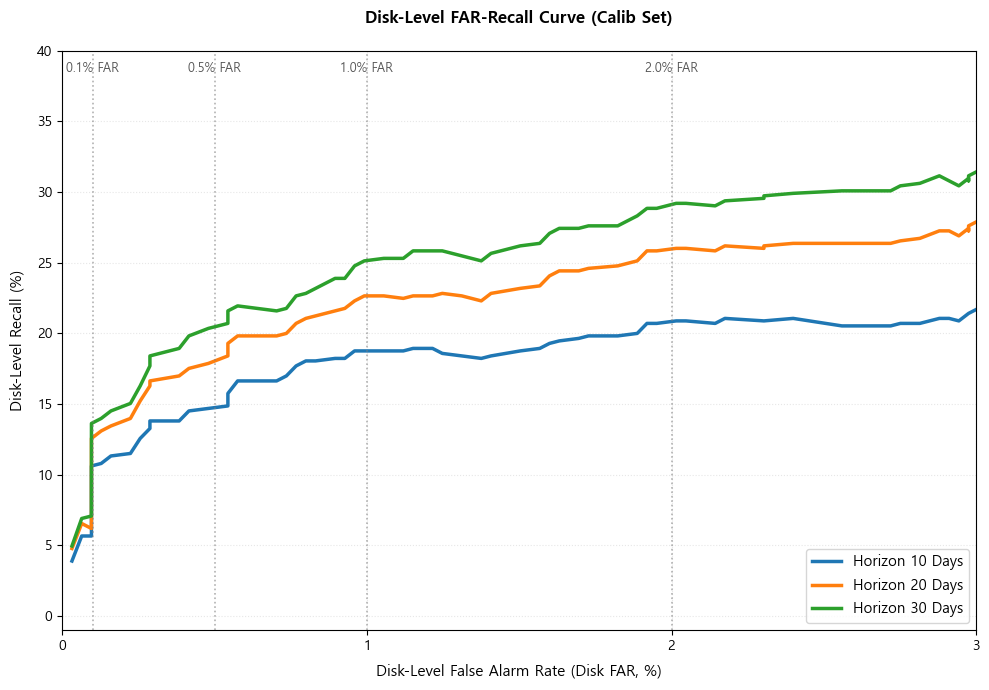

In [21]:
# 4. 통합 그래프 출력 (x축 3까지)
print('\n' + '='*100)
print('📈 통합 FAR-Recall 곡선 (Horizons: 10, 20, 30, 40, 50 Days)')
print('='*100)
plt.figure(figsize=(10, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, horizon in enumerate(horizons):
    df_grid = all_grids[horizon]
    sub_df = df_grid[df_grid['min_alarms'] == 1].sort_values('threshold', ascending=False)
    plot_df = sub_df[sub_df['far'] > 0]
    plt.plot(plot_df['far'] * 100, plot_df['recall'] * 100, color=colors[i], lw=2.5,
             label=f'Horizon {horizon} Days')

target_fars = [0.1, 0.5, 1.0, 2.0]
for tf in target_fars:
    plt.axvline(tf, color='#7f7f7f', linestyle=':', alpha=0.6, lw=1.2)
    plt.text(tf, 38.5, f'{tf}% FAR', color='#555555', fontsize=9, ha='center', fontweight='normal')

plt.xlim([0.0, 3.0])
plt.ylim([-1.0, 40.0])
plt.xticks(np.arange(0, 4, 1))

plt.xlabel('Disk-Level False Alarm Rate (Disk FAR, %)', fontsize=11, labelpad=8)
plt.ylabel('Disk-Level Recall (%)', fontsize=11, labelpad=8)
plt.title('Disk-Level FAR-Recall Curve (Calib Set)', fontsize=12, fontweight='bold', pad=20)
plt.legend(loc='lower right', fontsize=10.5)
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()